In [20]:
import torch
import torchvision
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [14]:
train_data = torchvision.datasets.MNIST(root = "data",
                                       train = True,
                                       transform = torchvision.transforms.ToTensor(),
                                       target_transform = None,
                                       download = True)

test_data = torchvision.datasets.MNIST(root = "data",
                                      train = False,
                                      transform = torchvision.transforms.ToTensor(),
                                      download = True,
                                      target_transform = None)

In [15]:
len(train_data), len(test_data)

(60000, 10000)

In [16]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [27]:
image, label = train_data[0]
image.shape

torch.Size([1, 28, 28])

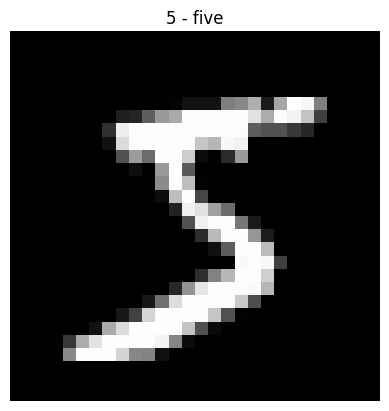

In [28]:
plt.imshow(image.squeeze(dim=0), cmap="gray")
plt.title(class_names[label])
plt.axis(False);

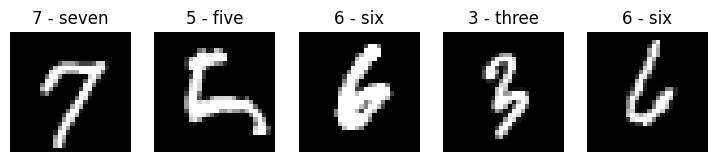

In [36]:
plt.figure(figsize = (9,9))
cols = 5
for i in range(1, cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    image, label = train_data[random_idx]
    plt.subplot(1,cols, i)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [38]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_data, batch_size = BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size = BATCH_SIZE, shuffle=False)
len(train_dataloader)   #60000/32 =1.875 

1875

In [42]:
class MNISTModel(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.layer_stack_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape,
                     out_channels = hidden_units,
                     kernel_size = 3,
                     stride = 1,
                     padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                     out_channels = hidden_units,
                     kernel_size = 3,
                     stride = 1,
                     padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )
        self.layer_stack_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units,
                     out_channels = hidden_units,
                     kernel_size = 3,
                     stride = 1,
                     padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                     out_channels = hidden_units,
                     kernel_size = 3,
                     stride = 1,
                     padding = 1),
            nn.ReLU(),
            nn.MaxPool2d( kernel_size = 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units*7*7, out_features = output_shape)
        )

    def forward(self, x):
        return self.classifier(self.layer_stack_2(self.layer_stack_1(x)))

In [46]:
model = MNISTModel(input_shape = 1, hidden_units = 10, output_shape = len(class_names))
model

MNISTModel(
  (layer_stack_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_stack_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [47]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr=0.01)

In [55]:
from helper_functions import accuracy_fn
torch.manual_seed(42)

train_loss, train_acc = 0,0
test_loss, test_acc = 0,0

epochs = 3
for epoch in range(epochs):
    print(f"------- Epoch: {epoch} -------\n")
    for X,y in train_dataloader:
        model.train()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        acc = accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim=1))
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        train_loss += loss
        train_acc += acc

    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    model.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y)
            test_acc += accuracy_fn(y_true = y, y_pred = y_pred.argmax(dim=1))

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)

    print(f"Train Loss: {train_loss} , Train Acc: {train_acc} | Test Loss {test_loss}, Test Acc {test_acc}") 

------- Epoch: 0 -------

Train Loss: 0.08767446130514145 , Train Acc: 97.35 | Test Loss 0.10960175096988678, Test Acc 96.71525559105432
------- Epoch: 1 -------

Train Loss: 0.08578876405954361 , Train Acc: 97.49525333333334 | Test Loss 0.08278307318687439, Test Acc 97.53343532137717
------- Epoch: 2 -------

Train Loss: 0.08638078719377518 , Train Acc: 97.53033080177778 | Test Loss 0.06912223994731903, Test Acc 98.05521864319928
